In [16]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
sys.path.insert(0, '/Users/student/Desktop/CPSC-4830-Final-Project')
from joint_graphst import JointGraphST, MLPClassifier, train_mlp, evaluate_model, run_joint_graphst

sys.path.insert(0, '../GraphST')

DATA_PATH = '../GraphST/Data/151673'
SECTION_ID = '151673'

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Scanpy:", sc.__version__)
print("CUDA available:", torch.cuda.is_available())

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

Python: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
PyTorch: 2.11.0
Scanpy: 1.11.5
CUDA available: False


In [18]:
# Load data
adata = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5', 
                       load_images=False)
adata.var_names_make_unique()

# Add spatial coordinates
positions = pd.read_csv(
    os.path.join(DATA_PATH, 'spatial', 'tissue_positions_list.csv'),
    header=None,
    names=['barcode','in_tissue','row','col','pxl_row','pxl_col'],
    index_col=0
)
adata.obs['array_row'] = positions.loc[adata.obs_names, 'row']
adata.obs['array_col'] = positions.loc[adata.obs_names, 'col']
adata.obsm['spatial'] = positions.loc[adata.obs_names, ['pxl_col','pxl_row']].values

# Add ground truth labels
metadata = pd.read_csv(os.path.join(DATA_PATH, 'metadata.tsv'), sep='\t', index_col=0)
adata.obs['layer'] = metadata.loc[adata.obs_names, 'layer_guess_reordered_short']

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [19]:
# Filter to annotated spots only
adata = adata[adata.obs['layer'].notna()].copy()

# Encode labels
le = LabelEncoder()
adata.obs['label_int'] = le.fit_transform(adata.obs['layer'])
n_classes = len(le.classes_)

print(adata)
print(f"\nClasses: {le.classes_}")
print(f"N classes: {n_classes}")

AnnData object with n_obs × n_vars = 4221 × 33538
    obs: 'array_row', 'array_col', 'layer', 'label_int'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

Classes: ['L1' 'L2' 'L3' 'L4' 'L5' 'L6' 'WM']
N classes: 7


In [20]:
# Train GraphST (directly following GraphST, no modifications yet)
from GraphST import GraphST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = GraphST.GraphST(adata, device=device)
adata = model.train()

# Check embeddings
emb = adata.obsm['emb']
print(f"\nEmbedding shape: {emb.shape}")
print(f"NaN count: {np.isnan(emb).sum()}")
print(f"Sample values: {emb[0, :5]}")

Using device: cpu
Begin to train ST data...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [03:25<00:00,  2.92it/s]

Optimization finished for ST data!

Embedding shape: (4221, 3000)
NaN count: 0
Sample values: [ 0.091976    0.24561952 -0.09968088  0.10631447  0.25271928]


In [28]:
# Evaluate GraphST clustering (baseline)
from sklearn.cluster import KMeans

# Get embeddings and true labels
embeddings = adata.obsm['emb']
true_labels = adata.obs['label_int'].values

# Cluster the embeddings with KMeans (standard approach from GraphST paper)
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Compute clustering metrics
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)

print("=== GraphST Clustering Performance ===")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"\nGraphST paper reports ARI ~0.50-0.60 on DLPFC")
print(f"(Single-slice result may vary slightly)")

=== GraphST Clustering Performance ===
ARI: 0.4162
NMI: 0.5322

GraphST paper reports ARI ~0.50-0.60 on DLPFC
(Single-slice result may vary slightly)


In [22]:
# MLP Classifier to assess how using GraphST embeddings as inputs
# helps with cortical layer prediction

# Prepare data
embeddings = np.nan_to_num(adata.obsm['emb'], nan=0.0)
true_labels = adata.obs['label_int'].values

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)

input_dim = embeddings.shape[1]
print(f"Input dim: {input_dim}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Training MLP classifier on GraphST embeddings...")

# Run MLP classification head on frozen GraphST embeddings
mlp_model = train_mlp(X_train, y_train, X_test, y_test,
                      input_dim=input_dim, num_classes=n_classes)

Input dim: 3000
Train size: 3376, Test size: 845
Training MLP classifier on GraphST embeddings...
Epoch  50 | Loss: 0.2789 | Val Macro-F1: 0.8075
Epoch 100 | Loss: 0.1188 | Val Macro-F1: 0.8564
Epoch 150 | Loss: 0.0572 | Val Macro-F1: 0.8648
Epoch 200 | Loss: 0.0334 | Val Macro-F1: 0.8784
Epoch 250 | Loss: 0.0226 | Val Macro-F1: 0.8772
Epoch 300 | Loss: 0.0181 | Val Macro-F1: 0.8688


In [29]:
# Evaluate all models and compare

from sklearn.neural_network import MLPClassifier as SklearnMLP
from sklearn.decomposition import PCA

# Frozen GraphST embeddings -> MLP
frozen_f1, frozen_auroc = evaluate_model(
    mlp_model, X_test, y_test, n_classes, device, "Frozen GraphST embeddings → MLP"
)

# Baseline 1: PCA features -> MLP (no spatial GNN)
X_raw = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
pca = PCA(n_components=200, random_state=42)
X_pca = pca.fit_transform(X_raw)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)
pca_mlp = SklearnMLP(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
pca_mlp.fit(X_pca_train, y_pca_train)
pca_preds = pca_mlp.predict(X_pca_test)
pca_probs = pca_mlp.predict_proba(X_pca_test)
pca_f1 = f1_score(y_pca_test, pca_preds, average='macro', zero_division=0)
pca_auroc = roc_auc_score(
    label_binarize(y_pca_test, classes=range(n_classes)),
    pca_probs, multi_class='ovr', average='macro'
)
print(f"\n=== Baseline: PCA → MLP (no spatial GNN) ===")
print(f"Macro-F1 : {pca_f1:.4f}")
print(f"AUROC    : {pca_auroc:.4f}")

# Baseline 2: Raw counts -> MLP (no GNN, no PCA)
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, true_labels, test_size=0.2, random_state=42, stratify=true_labels
)
raw_mlp = SklearnMLP(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
raw_mlp.fit(X_raw_train, y_raw_train)
raw_preds = raw_mlp.predict(X_raw_test)
raw_probs = raw_mlp.predict_proba(X_raw_test)
raw_f1 = f1_score(y_raw_test, raw_preds, average='macro', zero_division=0)
raw_auroc = roc_auc_score(
    label_binarize(y_raw_test, classes=range(n_classes)),
    raw_probs, multi_class='ovr', average='macro'
)
print(f"\n=== Baseline: Raw counts → MLP (no GNN, no PCA) ===")
print(f"Macro-F1 : {raw_f1:.4f}")
print(f"AUROC    : {raw_auroc:.4f}")

# --- SUMMARY TABLE ---
print("\n" + "="*50)
print(f"{'Model':<35} {'Macro-F1':>8} {'AUROC':>8}")
print("-"*50)
print(f"{'Raw counts → MLP':<35} {raw_f1:>8.4f} {raw_auroc:>8.4f}")
print(f"{'PCA → MLP':<35} {pca_f1:>8.4f} {pca_auroc:>8.4f}")
print(f"{'GraphST → MLP':<35} {frozen_f1:>8.4f} {frozen_auroc:>8.4f}")
print(f"\nGraphST clustering ARI: {ari:.4f} | NMI: {nmi:.4f}")


=== Frozen GraphST embeddings → MLP ===
Macro-F1 : 0.8784
AUROC    : 0.9905

=== Baseline: PCA → MLP (no spatial GNN) ===
Macro-F1 : 0.6211
AUROC    : 0.9270

=== Baseline: Raw counts → MLP (no GNN, no PCA) ===
Macro-F1 : 0.5606
AUROC    : 0.8957

Model                               Macro-F1    AUROC
--------------------------------------------------
Raw counts → MLP                      0.5606   0.8957
PCA → MLP                             0.6211   0.9270
GraphST → MLP                         0.8784   0.9905

GraphST clustering ARI: 0.4162 | NMI: 0.5322


In [32]:
# Joint Fine-Tuning & Ablation Study
# Semi-supervised GraphST: combined contrastive + classification loss

sys.path.insert(0, '/Users/student/Desktop/CPSC-4830-Final-Project')
from joint_graphst import run_joint_graphst

# Reload fresh adata (GraphST modified it earlier)
adata_fresh = sc.read_visium(DATA_PATH, count_file='filtered_feature_bc_matrix.h5',
                              load_images=False)
adata_fresh.var_names_make_unique()
positions_fresh = pd.read_csv(
    os.path.join(DATA_PATH, 'spatial', 'tissue_positions_list.csv'),
    header=None,
    names=['barcode','in_tissue','row','col','pxl_row','pxl_col'],
    index_col=0
)
adata_fresh.obs['array_row'] = positions_fresh.loc[adata_fresh.obs_names, 'row']
adata_fresh.obs['array_col'] = positions_fresh.loc[adata_fresh.obs_names, 'col']
adata_fresh.obsm['spatial'] = positions_fresh.loc[
    adata_fresh.obs_names, ['pxl_col','pxl_row']].values
metadata_fresh = pd.read_csv(os.path.join(DATA_PATH, 'metadata.tsv'), sep='\t', index_col=0)
adata_fresh.obs['layer'] = metadata_fresh['layer_guess_reordered_short'].reindex(adata_fresh.obs_names)
adata_fresh = adata_fresh[adata_fresh.obs['layer'].notna()].copy()
adata_fresh.obs['label_int'] = le.transform(adata_fresh.obs['layer'])

labels_all = adata_fresh.obs['label_int'].values
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Same train/test split as before
n = len(labels_all)
idx = np.arange(n)
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42,
                                        stratify=labels_all)
train_mask_ab = np.zeros(n, dtype=bool)
test_mask_ab = np.zeros(n, dtype=bool)
train_mask_ab[train_idx] = True
test_mask_ab[test_idx] = True

# Gamma values to ablate
# gamma=0: original GraphST (unsupervised pretraining only)
# gamma>0: semi-supervised extension
gammas = [0, 0.1, 0.5, 1.0, 5.0]
ablation_results = []

print("Running gamma ablation study...")
print("(Each run trains for 600 epochs\n")

for gamma in gammas:
    print(f"\n--- gamma = {gamma} ---")
    result = run_joint_graphst(
        adata_fresh, labels_all, train_mask_ab, test_mask_ab,
        n_classes=n_classes, gamma=gamma, device=device
    )
    ablation_results.append(result)
    print(f"Macro-F1: {result['macro_f1']:.4f} | AUROC: {result['auroc']:.4f} | "
          f"ARI: {result['ari']:.4f} | NMI: {result['nmi']:.4f}")

# Final results table
print("\n" + "="*70)
print(f"{'Model':<40} {'Macro-F1':>8} {'AUROC':>8} {'ARI':>7} {'NMI':>7}")
print("-"*70)
print(f"{'Raw counts → MLP':<40} {raw_f1:>8.4f} {raw_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'PCA → MLP':<40} {pca_f1:>8.4f} {pca_auroc:>8.4f} {'—':>7} {'—':>7}")
print(f"{'GraphST → MLP (frozen)':<40} {frozen_f1:>8.4f} {frozen_auroc:>8.4f} {ari:>7.4f} {nmi:>7.4f}")
print("-"*70)

for r in ablation_results:
    label = f"Joint GraphST (gamma={r['gamma']})"
    print(f"{label:<40} {r['macro_f1']:>8.4f} {r['auroc']:>8.4f} "
          f"{r['ari']:>7.4f} {r['nmi']:>7.4f}")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

Running gamma ablation study...
(Each run trains for 600 epochs


--- gamma = 0 ---


gamma=0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [07:17<00:00,  1.37it/s]


Macro-F1: 0.1055 | AUROC: 0.4908 | ARI: 0.4162 | NMI: 0.5322

--- gamma = 0.1 ---


gamma=0.1: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [08:01<00:00,  1.25it/s]


Macro-F1: 0.8174 | AUROC: 0.9697 | ARI: 0.3900 | NMI: 0.5316

--- gamma = 0.5 ---


...

Macro-F1: 0.8504 | AUROC: 0.9776 | ARI: 0.4549 | NMI: 0.5641

--- gamma = 1.0 ---


gamma=1.0: 100%|████████████████████████████████| 600/600 [03:39<00:00,  2.74it/s]


Macro-F1: 0.8727 | AUROC: 0.9822 | ARI: 0.4558 | NMI: 0.5664

--- gamma = 5.0 ---


gamma=5.0: 100%|████████████████████████████████| 600/600 [03:40<00:00,  2.73it/s]


Macro-F1: 0.9100 | AUROC: 0.9885 | ARI: 0.4542 | NMI: 0.5657

Model                                    Macro-F1    AUROC     ARI     NMI
----------------------------------------------------------------------
Raw counts → MLP                           0.5606   0.8957       —       —
PCA → MLP                                  0.6211   0.9270       —       —
GraphST → MLP (frozen)                     0.8784   0.9905  0.4162  0.5322
----------------------------------------------------------------------
Joint GraphST (gamma=0)                    0.1055   0.4908  0.4162  0.5322
Joint GraphST (gamma=0.1)                  0.8174   0.9697  0.3900  0.5316
Joint GraphST (gamma=0.5)                  0.8504   0.9776  0.4549  0.5641
Joint GraphST (gamma=1.0)                  0.8727   0.9822  0.4558  0.5664
Joint GraphST (gamma=5.0)                  0.9100   0.9885  0.4542  0.5657


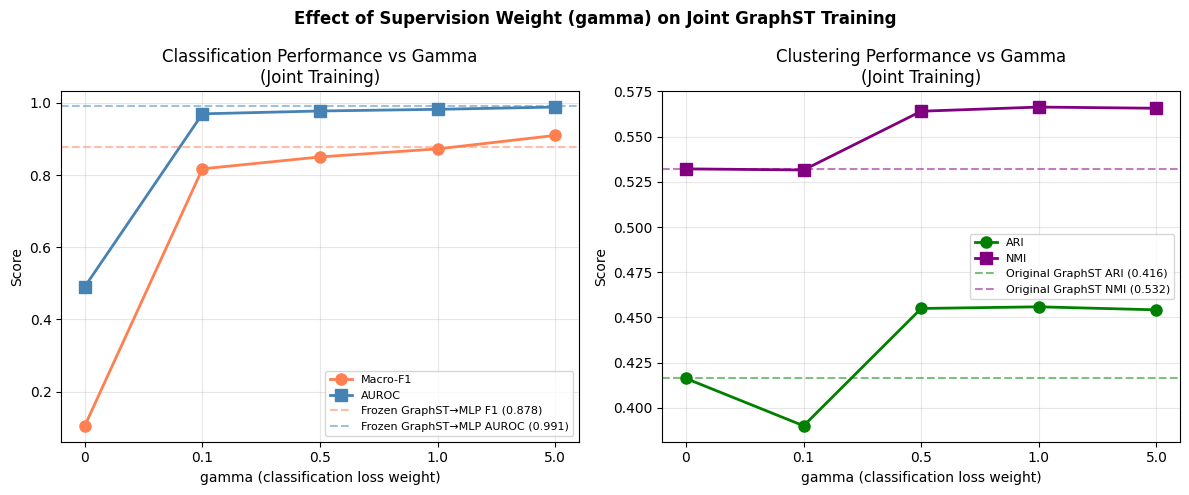

Figure saved!


In [31]:
# Visualize gamma ablation results (fixed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gammas_plot = [r['gamma'] for r in ablation_results]
f1_plot     = [r['macro_f1'] for r in ablation_results]
auroc_plot  = [r['auroc'] for r in ablation_results]
ari_plot    = [r['ari'] for r in ablation_results]
nmi_plot    = [r['nmi'] for r in ablation_results]

x_ticks = list(range(len(gammas_plot)))  # 0,1,2,3,4 as positions
x_labels = [str(g) for g in gammas_plot]  # '0','0.1','0.5','1.0','5.0'

# Plot 1: Classification metrics
axes[0].plot(x_ticks, f1_plot, 'o-', color='coral', linewidth=2,
             markersize=8, label='Macro-F1')
axes[0].plot(x_ticks, auroc_plot, 's-', color='steelblue', linewidth=2,
             markersize=8, label='AUROC')
axes[0].axhline(y=frozen_f1, color='coral', linestyle='--', alpha=0.5,
                label=f'Frozen GraphST→MLP F1 ({frozen_f1:.3f})')
axes[0].axhline(y=frozen_auroc, color='steelblue', linestyle='--', alpha=0.5,
                label=f'Frozen GraphST→MLP AUROC ({frozen_auroc:.3f})')
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel('gamma (classification loss weight)')
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Performance vs Gamma\n(Joint Training)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Plot 2: Clustering metrics
axes[1].plot(x_ticks, ari_plot, 'o-', color='green', linewidth=2,
             markersize=8, label='ARI')
axes[1].plot(x_ticks, nmi_plot, 's-', color='purple', linewidth=2,
             markersize=8, label='NMI')
axes[1].axhline(y=ari, color='green', linestyle='--', alpha=0.5,
                label=f'Original GraphST ARI ({ari:.3f})')
axes[1].axhline(y=nmi, color='purple', linestyle='--', alpha=0.5,
                label=f'Original GraphST NMI ({nmi:.3f})')
axes[1].set_xticks(x_ticks)
axes[1].set_xticklabels(x_labels)
axes[1].set_xlabel('gamma (classification loss weight)')
axes[1].set_ylabel('Score')
axes[1].set_title('Clustering Performance vs Gamma\n(Joint Training)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Effect of Supervision Weight (gamma) on Joint GraphST Training',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/student/Desktop/CPSC-4830-Final-Project/figures/gamma_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

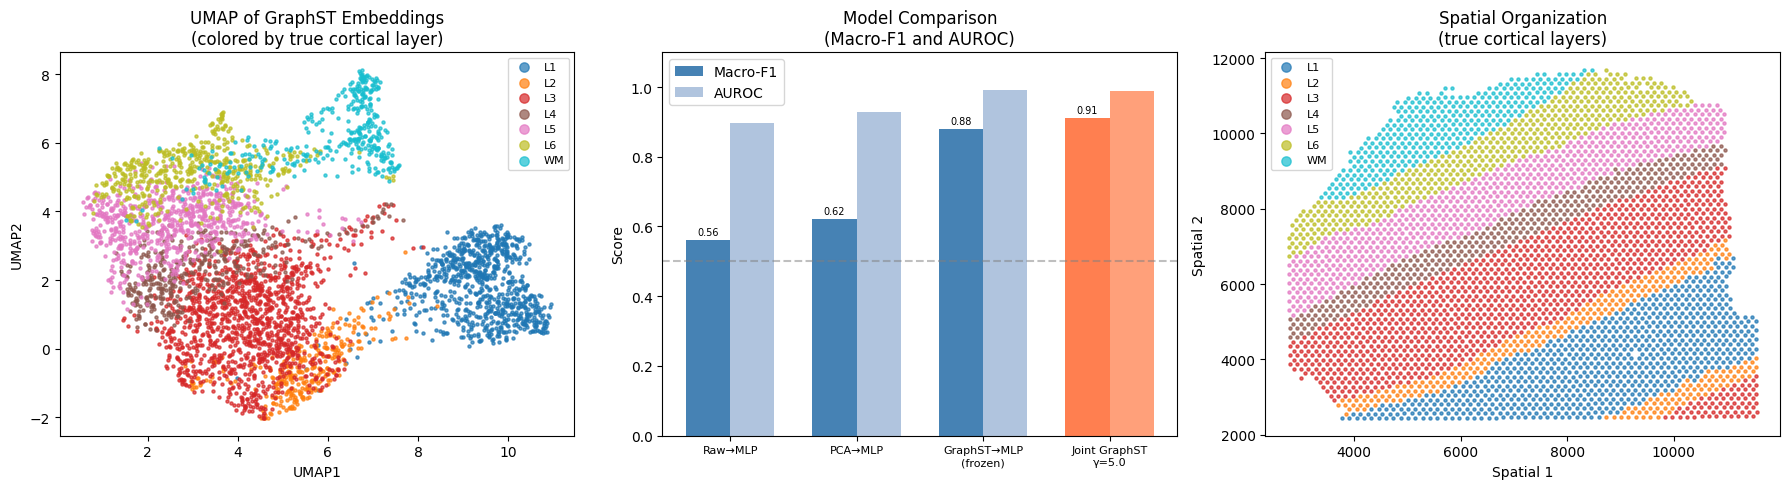

Figure saved!


In [30]:
# Visualizations for report
import umap
import matplotlib.pyplot as plt

os.makedirs('/Users/student/Desktop/CPSC-4830-Final-Project/figures', exist_ok=True)
FIGURES_PATH = '/Users/student/Desktop/CPSC-4830-Final-Project/figures'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: UMAP of GraphST Embeddings colored by true layer
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
embedding_2d = reducer.fit_transform(np.nan_to_num(adata.obsm['emb']))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, layer in enumerate(le.classes_):
    mask = adata.obs['label_int'].values == i
    axes[0].scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
                   c=[colors[i]], label=layer, s=5, alpha=0.7)
axes[0].set_title('UMAP of GraphST Embeddings\n(colored by true cortical layer)')
axes[0].legend(markerscale=3, fontsize=8)
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

# Plot 2: Bar chart of results
models = ['Raw→MLP', 'PCA→MLP', 'GraphST→MLP\n(frozen)', 'Joint GraphST\nγ=5.0']
f1_scores = [raw_f1, pca_f1, frozen_f1, 0.9100]
auroc_scores = [raw_auroc, pca_auroc, frozen_auroc, 0.9885]

x = np.arange(len(models))
width = 0.35
bars1 = axes[1].bar(x - width/2, f1_scores, width, label='Macro-F1',
                     color=['steelblue']*3 + ['coral'])
bars2 = axes[1].bar(x + width/2, auroc_scores, width, label='AUROC',
                     color=['lightsteelblue']*3 + ['lightsalmon'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Comparison\n(Macro-F1 and AUROC)')
axes[1].legend()
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# --- Plot 3: Spatial plot of true layers ---
spatial = adata.obsm['spatial']
for i, layer in enumerate(le.classes_):
    mask = adata.obs['label_int'].values == i
    axes[2].scatter(spatial[mask, 0], spatial[mask, 1],
                   c=[colors[i]], label=layer, s=5, alpha=0.7)
axes[2].set_title('Spatial Organization\n(true cortical layers)')
axes[2].legend(markerscale=3, fontsize=8)
axes[2].set_xlabel('Spatial 1')
axes[2].set_ylabel('Spatial 2')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved!")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)